Checking language type distribution in existing pretraining corpora

In [1]:
import os
import pandas as pd
import tiktoken
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from huggingface_hub import HfApi, hf_hub_download

tqdm.pandas()

FONT_SIZES = {"small": 14, "medium": 18, "large": 24}

PLOT_PARAMS = {
    "font.family": "serif",
    "font.serif": ["Times"],
    "font.size": FONT_SIZES.get("medium"),
    "axes.titlesize": FONT_SIZES.get("large"),
    "axes.labelsize": FONT_SIZES.get("large"),
    "xtick.labelsize": FONT_SIZES.get("large"),
    "ytick.labelsize": FONT_SIZES.get("large"),
    "legend.fontsize": FONT_SIZES.get("medium"),
    "figure.titlesize": FONT_SIZES.get("medium"),
    "text.usetex": True,
}

plt.rcParams.update(PLOT_PARAMS)

/Users/ljvmiranda/Developer/scratch/2026-03-20-madlad/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_madlad(lang: str, split: str = "clean_docs") -> pd.DataFrame:
    """Load MADLAD-400 data for a given language code into a DataFrame.

    Args:
        lang: Language code (e.g. 'ceb', 'tgl', 'en').
        split: Which split to load — 'clean_docs', 'noisy_docs', or 'all'.
    """
    api = HfApi()
    files = api.list_repo_tree(
        "allenai/MADLAD-400",
        path_in_repo=f"data-v1p5/{lang}",
        repo_type="dataset",
    )

    local_dir = f"data/{lang}"
    os.makedirs(local_dir, exist_ok=True)

    paths = []
    for f in files:
        if not f.rfilename.endswith(".jsonl.gz"):
            continue
        if split != "all" and split not in f.rfilename:
            continue
        path = hf_hub_download(
            "allenai/MADLAD-400",
            filename=f.rfilename,
            repo_type="dataset",
            local_dir=local_dir,
        )
        paths.append(path)

    print(f"Downloaded {len(paths)} files for '{lang}'")
    return pd.concat([pd.read_json(p, lines=True) for p in paths], ignore_index=True)

In [3]:
df = load_madlad("ceb", split="clean_docs")
df.head(5)

Downloaded 10 files for 'ceb'


,text,timestamp,url
0,Ang Brand Africa nga nagpadayon sa pagsugat sa...,2021-09-24 00:24:28+00:00,https://ceb.eturbonews.com/165852/brand-africa...
1,"Gipalihok pinaagi sa Hiyas sa pagtugnaw, pagla...",2022-05-22 18:13:01+00:00,https://cleverplus.news/news/1409-ya_no_vayas_...
2,Ang Apple adunay labing kapuslan nga mga tinda...,2021-09-26 04:32:23+00:00,https://www.soydemac.com/ceb/apple-ang-labing-...
3,Hotels.com helps you to find the best hotel fo...,2021-11-27 03:08:03+00:00,https://sg.hotels.com/de700471/ugento-italy-ho...
4,Purohan batok COVID-19 | Banat\nPurohan batok ...,2020-11-28 12:00:41+00:00,https://www.philstar.com/banat/opinyon/2020/06...


Before we do some fun stuff, might be nice to just learn more about the data

In [4]:
enc = tiktoken.get_encoding("cl100k_base")
df["token_length"] = df["text"].progress_apply(lambda x: len(enc.encode(x)))

100%|██████████| 66164/66164 [00:22<00:00, 2881.34it/s]


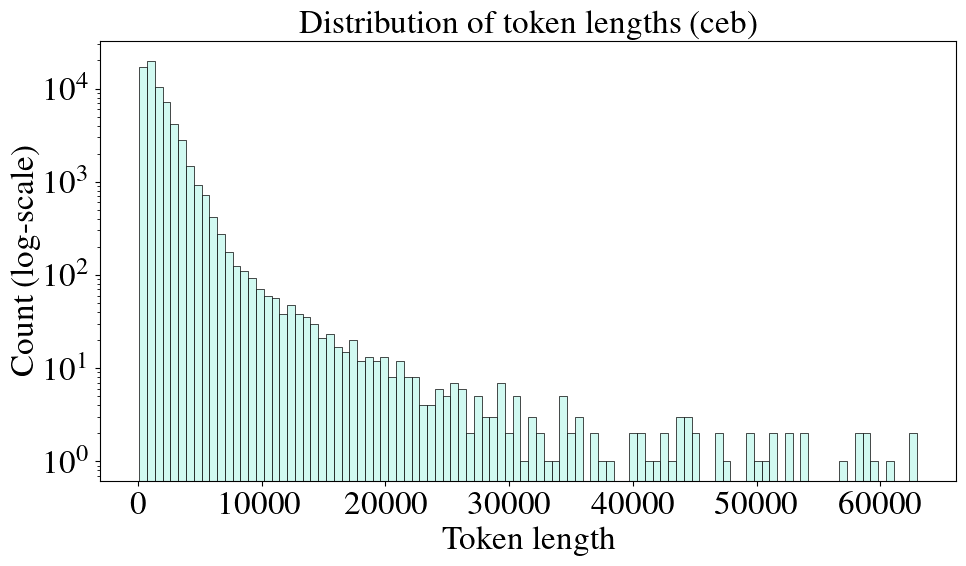

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["token_length"], bins=100, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.set_yscale("log")
ax.set_xlabel("Token length")
ax.set_ylabel("Count (log-scale)")
ax.set_title("Distribution of token lengths (ceb)")
fig.tight_layout()
plt.show()

Ideally, I'd check each text and confirm which data type they have. But assuming I don't have any knowledge about the language, what can I do? Maybe...

- Check the URLs? Perhaps there's a way to cross-reference URLs to a certain domain.
- Use an LLM? Maybe something like [this work](https://arxiv.org/pdf/2502.10341). But how do you validate this?

Let's start by checking the URLs

In [6]:
from urllib.parse import urlparse

df["tld"] = df["url"].apply(lambda x: "." + urlparse(x).netloc.rsplit(".", 1)[-1])

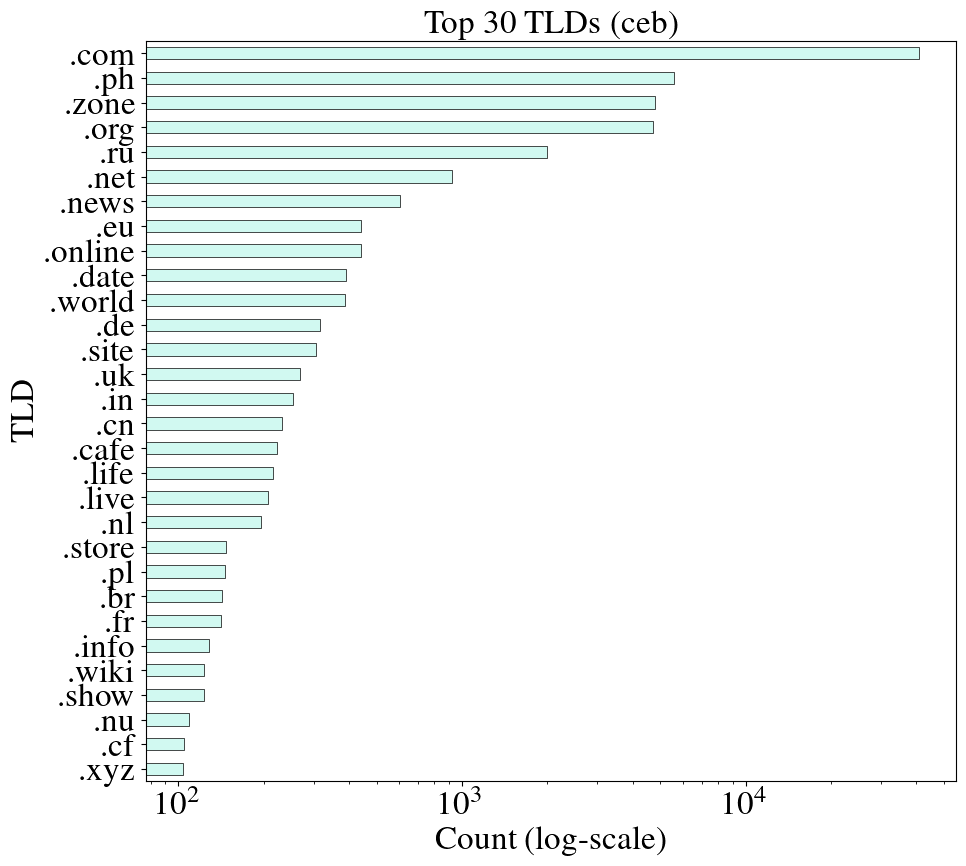

In [7]:
top_n = 30
tld_counts = df["tld"].value_counts().head(top_n)

fig, ax = plt.subplots(figsize=(10, 9))
tld_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("Count (log-scale)")
ax.set_ylabel("TLD")
ax.set_title(f"Top {top_n} TLDs (ceb)")
fig.tight_layout()
plt.show()

### Topic classification

Using [WebOrganizer/TopicClassifier](https://huggingface.co/WebOrganizer/TopicClassifier) to classify documents into 24 topic categories.

In [13]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

TOPIC_LABELS = {
    0: "Adult",
    1: "Art & Design",
    2: "Software Dev.",
    3: "Crime & Law",
    4: "Education & Jobs",
    5: "Hardware",
    6: "Entertainment",
    7: "Social Life",
    8: "Fashion & Beauty",
    9: "Finance & Business",
    10: "Food & Dining",
    11: "Games",
    12: "Health",
    13: "History",
    14: "Home & Hobbies",
    15: "Industrial",
    16: "Literature",
    17: "Politics",
    18: "Religion",
    19: "Science & Tech.",
    20: "Software",
    21: "Sports & Fitness",
    22: "Transportation",
    23: "Travel",
}

device = torch.device("cpu")

topic_tokenizer = AutoTokenizer.from_pretrained("WebOrganizer/TopicClassifier")
topic_model = (
    AutoModelForSequenceClassification.from_pretrained(
        "WebOrganizer/TopicClassifier",
        trust_remote_code=True,
        use_memory_efficient_attention=False,
        torch_dtype=torch.float32,
    )
    .to(device)
    .eval()
)

Loading weights: 100%|██████████| 139/139 [00:00<00:00, 16686.94it/s]


In [16]:
@torch.no_grad()
def classify_topic(text: str, url: str = "") -> str:
    """Classify a single document into one of 24 topic categories."""
    input_text = f"{url}\n\n{text}" if url else text
    inputs = topic_tokenizer([input_text], return_tensors="pt", truncation=True).to(
        device
    )
    seq_len = inputs["input_ids"].shape[1]
    inputs["position_ids"] = torch.arange(
        seq_len, dtype=torch.long, device=device
    ).unsqueeze(0)
    outputs = topic_model(**inputs)
    pred = outputs.logits.softmax(dim=-1).argmax(dim=-1).item()
    return TOPIC_LABELS[pred]


# Quick test
print("{url}\nn{text}".format(url=df["url"].iloc[0], text=df["text"].iloc[0]))
classify_topic(df["text"].iloc[0], df["url"].iloc[0])

https://ceb.eturbonews.com/165852/brand-africa-nga-nagpadayon-sa-unahan-sa-zambia-nagtagbo-sa-mga-asosasyon-sa-pagdumala-sa-pantalan/
nAng Brand Africa nga nagpadayon sa pagsugat sa Zambia sa Ports Management Association\nHome » Pinakabag-ong Mga Artikulo sa Balita » Mga Kasayuran nga Balita » Ang Brand Africa nga nagpadayon sa pagsugat sa Zambia sa Ports Management Association\nMga Kasayuran nga Balita • Pagbungkag sa Balita sa Pagbiyahe • Pag-cruis • Balita • Turismo • Transportation • Pagbag-o sa Destinasyon sa Pagbiyahe • Balita sa Travel Wire • Balita sa Pagbungkag sa Zambia\nAng Ministro sa Turismo ug Sining nga si Hon. Gisulti ni Charles Banda nga ang Zambia sa dili madugay makita kung unsa ang labing kaayo aron mapalambo ang turismo sa cruise pinaagi sa paggamit sa mga magamit nga mga tubig nga tubig ingon ang Seychelles 'Head of Mission sa Zambia, si Jamil (Jimmy) Butt, nagsulti nga ang iyang nasud gusto nga magtubo ang usa ka bilateral nga panaghigalaay sa linya sa Kasabutan 

'Adult'

In [20]:
df_sample = df.sample(100)
df_sample["topic"] = df_sample.progress_apply(
    lambda row: classify_topic(row["text"], row["url"]), axis=1
)

100%|██████████| 100/100 [00:41<00:00,  2.43it/s]


In [ ]:
topic_counts = df_sample["topic"].value_counts()
topic_counts

topic
Health                14
Finance & Business    10
Industrial            10
Fashion & Beauty       8
Science & Tech.        7
Politics               7
Religion               6
Literature             4
Food & Dining          4
Social Life            3
Transportation         3
Crime & Law            3
Sports & Fitness       3
Hardware               3
Travel                 3
Entertainment          3
Software               2
Art & Design           2
Home & Hobbies         2
Games                  2
Education & Jobs       1
Name: count, dtype: int64

In [ ]:
df_sample[["topic", "text", "url"]].

topic                                           Literature
text     Sobra ra ba Kaayo Kang Makatrabaho?\nPANGUNANG...
url      https://www.jw.org/ceb/mga-publikasyon/mga-mag...
Name: 30772, dtype: str

In [28]:
topic_counts = df_sample["topic"].value_counts()

fig, ax = plt.subplots(figsize=(10, 8))
topic_counts.plot.barh(ax=ax, color="#D1F9F1", edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel("Count")
ax.set_ylabel("Topic")
ax.set_title("Topic distribution (ceb)")
fig.tight_layout()
plt.show()

RuntimeError: latex was not able to process the following string:
b'Finance & Business'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/psnfss/mathptmx.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/geomet

Error in callback <function _draw_all_if_interactive at 0x122ea9c60> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'Finance & Business'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/psnfss/mathptmx.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/geomet

RuntimeError: latex was not able to process the following string:
b'Finance & Business'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error file.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./file.tex
LaTeX2e <2024-11-01> patch level 2
L3 programming layer <2025-01-18>
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/06/29 v1.4n Standard LaTeX document class
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2025/texmf-dist/tex/latex/psnfss/mathptmx.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2025/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/texlive/2025/texmf-dist/tex/latex/geomet

<Figure size 1000x800 with 1 Axes>